# TITLE: Financial Complaint Router & Dispute-Risk Predictor

## Phase 1: Foundation

In [4]:
# Downloading dependencies

!pip install -q keybert sentence-transformers spacy
!python -m spacy download en_core_web_sm -q
!pip install -q lightgbm
!pip install -q shap

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 83.1 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer

from keybert import KeyBERT
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

import spacy
import re

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

from lightgbm import LGBMClassifier

import shap
from collections import Counter
import json

### STEP 1: Get real complaint data

In [6]:
df = pd.read_csv("complaints.csv")
df.head(5)

,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Submitted via,Date sent to company,Company response to consumer,Timely response?,Complaint ID
0,2026-02-05T19:40:33.000Z,Credit card,General-purpose credit card or charge card,Closing your account,Can't close your account,I received a One pay card in the mail that I n...,Company has responded to the consumer and the ...,SYNCHRONY FINANCIAL,OH,45177,Older American,Web,2026-04-14T20:51:43.000Z,Closed with explanation,Yes,19282132
1,2026-02-16T16:54:06.000Z,Debt collection,Auto debt,Communication tactics,Frequent or repeated calls,i am formally disputing the accuracy XXXX val...,Company has responded to the consumer and the ...,CREDIT ACCEPTANCE CORPORATION,AR,72315,NaN,Web,2026-02-16T17:10:04.000Z,Closed with explanation,Yes,19529643
2,2026-02-16T15:12:43.000Z,Vehicle loan or lease,Loan,Managing the loan or lease,Problem with additional products or services p...,I inquired about a used vehicle and the the pr...,Company has responded to the consumer and the ...,CREDIT ACCEPTANCE CORPORATION,MI,48227,NaN,Web,2026-02-16T15:24:39.000Z,Closed with explanation,Yes,19526673
3,2026-02-16T17:18:47.000Z,Checking or savings account,Savings account,Problem with a lender or other company chargin...,Transaction was not authorized,"On XX/XX/year>, {$10000.00} was transfered fro...",Company has responded to the consumer and the ...,PENTAGON FEDERAL CREDIT UNION,VA,23233,Servicemember,Web,2026-02-16T17:56:45.000Z,Closed with explanation,Yes,19531055
4,2026-02-16T16:30:00.000Z,Debt collection,I do not know,Attempts to collect debt not owed,Debt was result of identity theft,CREDIT COLL is falsely reporting on my credit....,Company believes it acted appropriately as aut...,"CCS Financial Services, Inc.",SC,293XX,NaN,Web,2026-02-16T16:34:01.000Z,Closed with explanation,Yes,19528513


In [7]:
print(f"Loaded {len(df)} rows")
print(df.columns.tolist())

Loaded 4890 rows
['Date received', 'Product', 'Sub-product', 'Issue', 'Sub-issue', 'Consumer complaint narrative', 'Company public response', 'Company', 'State', 'ZIP code', 'Tags', 'Submitted via', 'Date sent to company', 'Company response to consumer', 'Timely response?', 'Complaint ID']


In [8]:
print("Rows with narrative text:", df["Consumer complaint narrative"].notna().sum())
print("Rows with public response:", df["Company public response"].notna().sum())

Rows with narrative text: 4890
Rows with public response: 4890


In [9]:
df = df[df["Consumer complaint narrative"].notna()]
df = df[df["Company public response"].notna()]

#Dropping narratives that are too short
df = df[df["Consumer complaint narrative"].str.len() > 50]

df = df.reset_index(drop=True)

print(f"Final usable rows: {len(df)}")
df.head(3)

Final usable rows: 4888


,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Submitted via,Date sent to company,Company response to consumer,Timely response?,Complaint ID
0,2026-02-05T19:40:33.000Z,Credit card,General-purpose credit card or charge card,Closing your account,Can't close your account,I received a One pay card in the mail that I n...,Company has responded to the consumer and the ...,SYNCHRONY FINANCIAL,OH,45177,Older American,Web,2026-04-14T20:51:43.000Z,Closed with explanation,Yes,19282132
1,2026-02-16T16:54:06.000Z,Debt collection,Auto debt,Communication tactics,Frequent or repeated calls,i am formally disputing the accuracy XXXX val...,Company has responded to the consumer and the ...,CREDIT ACCEPTANCE CORPORATION,AR,72315,NaN,Web,2026-02-16T17:10:04.000Z,Closed with explanation,Yes,19529643
2,2026-02-16T15:12:43.000Z,Vehicle loan or lease,Loan,Managing the loan or lease,Problem with additional products or services p...,I inquired about a used vehicle and the the pr...,Company has responded to the consumer and the ...,CREDIT ACCEPTANCE CORPORATION,MI,48227,NaN,Web,2026-02-16T15:24:39.000Z,Closed with explanation,Yes,19526673


In [10]:
df.isnull().sum()

,0
Date received,0
Product,0
Sub-product,0
Issue,0
Sub-issue,0
Consumer complaint narrative,0
Company public response,0
Company,0
State,31
ZIP code,25


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4888 entries, 0 to 4887
Data columns (total 16 columns):
 #   Column                        Non-Null Count  Dtype 
---  ------                        --------------  ----- 
 0   Date received                 4888 non-null   object
 1   Product                       4888 non-null   object
 2   Sub-product                   4888 non-null   object
 3   Issue                         4888 non-null   object
 4   Sub-issue                     4888 non-null   object
 5   Consumer complaint narrative  4888 non-null   object
 6   Company public response       4888 non-null   object
 7   Company                       4888 non-null   object
 8   State                         4857 non-null   object
 9   ZIP code                      4863 non-null   object
 10  Tags                          798 non-null    object
 11  Submitted via                 4888 non-null   object
 12  Date sent to company          4888 non-null   object
 13  Company response t

## Cleaning the placeholders

In [12]:
def clean_narrative(text):
  text=re.sub(r'X{2,}[/\-]?', '', text)
  text=re.sub(r'\s+', ' ', text).strip()
  return text

df["Clean Consumer complaint narrative"] = df["Consumer complaint narrative"].apply(clean_narrative)
df["Clean Company public response"] = df["Company public response"].apply(clean_narrative)

In [13]:
print("Original:")
print(df["Consumer complaint narrative"].iloc[16][:300])
print("\nCleaned:")
print(df["Clean Consumer complaint narrative"].iloc[16][:300])

Original:
I called on the morning of XX/XX/XXXX to get replacement. They verified my identity 2x via text and 2x email and then the representative I spoke with must have done something so my card couldnt be replaced. They transfer me, he said he cant verify my identity. I ask to speak with a supervisor. She t

Cleaned:
I called on the morning of to get replacement. They verified my identity 2x via text and 2x email and then the representative I spoke with must have done something so my card couldnt be replaced. They transfer me, he said he cant verify my identity. I ask to speak with a supervisor. She too, cant se


## Phase 2: Text Understanding (3-way comparison)

Approach 1: TF-IDF Keyword Extraction

In [14]:
tfidf = TfidfVectorizer(max_features=5000, stop_words="english", ngram_range=(1, 2))
tfidf_matrix = tfidf.fit_transform(df["Clean Consumer complaint narrative"])

print("TF-IDF matrix shape: ", tfidf_matrix.shape)

TF-IDF matrix shape:  (4888, 5000)


In [15]:
def get_top_tfidf_keywords(row_index, tfidf_matrix, tfidf_model, top_n=5):
  feature_names = tfidf_model.get_feature_names_out()
  row = tfidf_matrix[row_index].toarray().flatten()
  top_indices = row.argsort()[-top_n:][::-1]
  top_keywords = [(feature_names[i], round(row[i], 3)) for i in top_indices if row[i] > 0]
  return top_keywords

example_index = 16
print("Complaint text:")
print(df["Clean Consumer complaint narrative"].iloc[example_index][:300], "...\n")

print("Top TF-IDF keywords:")
for word, score in get_top_tfidf_keywords(example_index, tfidf_matrix, tfidf):
    print(f"  {word}: {score}")

Complaint text:
I called on the morning of to get replacement. They verified my identity 2x via text and 2x email and then the representative I spoke with must have done something so my card couldnt be replaced. They transfer me, he said he cant verify my identity. I ask to speak with a supervisor. She too, cant se ...

Top TF-IDF keywords:
  text: 0.414
  verify identity: 0.357
  verify: 0.328
  identity: 0.313
  way: 0.233


Approach 2: KeyBERT Phrase Extraction

In [16]:
kw_model = KeyBERT(model="all-MiniLM-L6-v2")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [17]:
def get_keybert_keywords(text, kw_model, top_n=5):
  keywords = kw_model.extract_keywords(
      text,
      keyphrase_ngram_range=(1, 3),
      stop_words="english",
      top_n=top_n)
  return keywords

example_text = df["Clean Consumer complaint narrative"].iloc[example_index]
print("Complaint text:")
print(example_text[:300], "...\n")

print("Top KeyBERT keywords:")
for word, score in get_keybert_keywords(example_text, kw_model):
  print(f"{word}: {round(score,3)}")

Complaint text:
I called on the morning of to get replacement. They verified my identity 2x via text and 2x email and then the representative I spoke with must have done something so my card couldnt be replaced. They transfer me, he said he cant verify my identity. I ask to speak with a supervisor. She too, cant se ...

Top KeyBERT keywords:
citi verify identity: 0.553
verify identity ask: 0.52
replacement verified identity: 0.517
replacement verified: 0.497
citi verify: 0.496


In [18]:
# to ensure diversity
def get_keybert_phrases_keywords(text, kw_model, top_n=5):
  keywords = kw_model.extract_keywords(
      text,
      keyphrase_ngram_range=(1, 3),
      stop_words="english",
      top_n=top_n,
      use_mmr=True,
      diversity=0.5)
  return keywords

example_text = df["Clean Consumer complaint narrative"].iloc[example_index]
print("Complaint text:")
print(example_text[:300], "...\n")

print("Top KeyBERT keywords:")
for word, score in get_keybert_phrases_keywords(example_text, kw_model):
  print(f"{word}: {round(score,3)}")

Complaint text:
I called on the morning of to get replacement. They verified my identity 2x via text and 2x email and then the representative I spoke with must have done something so my card couldnt be replaced. They transfer me, he said he cant verify my identity. I ask to speak with a supervisor. She too, cant se ...

Top KeyBERT keywords:
citi verify identity: 0.553
supervisor send text: 0.472
text way verify: 0.461
card replaced transfer: 0.382
2x email representative: 0.374


Approach 3: NER

In [19]:
nlp = spacy.load("en_core_web_sm")

In [20]:
def extract_entities(text):
  doc = nlp(text)
  entities = [(ent.text, ent.label_) for ent in doc.ents]
  return entities

example_entities = extract_entities(example_text)
print("Clean Complaint text:")
print(example_text[:300], "...\n")

print("Entities:")
for entity, label in example_entities:
  print(f"{entity}: {label}")

Clean Complaint text:
I called on the morning of to get replacement. They verified my identity 2x via text and 2x email and then the representative I spoke with must have done something so my card couldnt be replaced. They transfer me, he said he cant verify my identity. I ask to speak with a supervisor. She too, cant se ...

Entities:
the morning: TIME
2x: CARDINAL
2x: CARDINAL
7-10 days: DATE
Citi: GPE


In [21]:
known_companies = set(df["Company"].dropna().str.lower().unique())
print(f"Number of unique companies in dataset: {len(known_companies)}")

Number of unique companies in dataset: 244


In [22]:
def extract_entities_with_override(text, known_companies):
  doc = nlp(text)
  entities = []
  for ent in doc.ents:
    label = ent.label_
    ent_lower = ent.text.lower()
    is_known_company = any(ent_lower in company or company in ent_lower for company in known_companies)

    if is_known_company:
      label = "ORG"
    entities.append((ent.text, label))
  return entities

result = extract_entities_with_override(example_text, known_companies)
print("Entities (with proper company names):")
for entity, label in result:
  print(f"{entity}: {label}")

Entities (with proper company names):
the morning: TIME
2x: CARDINAL
2x: CARDINAL
7-10 days: DATE
Citi: ORG


Comparing the 3 approaches

In [23]:
def compare_models(row_index, df, tfidf_matrix, tfidf_model, kw_model, known_companies):
  text = df["Clean Consumer complaint narrative"].iloc[row_index]
  print("Complaint text:")
  print(text[:200], "...\n")

  print("TF-IDF keywords:")
  for word, score in get_top_tfidf_keywords(row_index, tfidf_matrix, tfidf_model, top_n=3):
    print(f"{word}: {score}")

  print("\nKeyBERT keywords:")
  for word, score in get_keybert_phrases_keywords(text, kw_model, top_n=3):
    print(f"{word}: {score}")

  print("\nNER Entities:")
  entities = extract_entities_with_override(text, known_companies)
  for entity, label in entities:
    print(f"{entity}: {label}")

for i in range(4):
  print(f"\nComplaint {i+1}:")
  print("*"*50)
  compare_models(i, df, tfidf_matrix, tfidf, kw_model, known_companies)
  print("="*50)


Complaint 1:
**************************************************
Complaint text:
I received a One pay card in the mail that I never applied for. I've tried unsuccessfully different times to have it closed. Today I got email saying my statement is available. So I chatted with the p ...

TF-IDF keywords:
today: 0.371
times: 0.295
demanded: 0.258

KeyBERT keywords:
received pay card: 0.5375
address ss refused: 0.5254
different times closed: 0.2011

NER Entities:
One: ORG
Today: DATE
today: DATE
SS: ORG
3: CARDINAL

Complaint 2:
**************************************************
Complaint text:
i am formally disputing the accuracy validity of the account This dispute is made pursuant my rights under the Fair Credit reporting Act ( FCRA ), ( a ) ( ) ...

TF-IDF keywords:
pursuant rights: 0.344
disputing accuracy: 0.342
account dispute: 0.342

KeyBERT keywords:
validity account dispute: 0.7162
reporting act fcra: 0.5117
formally disputing accuracy: 0.4839

NER Entities:
the Fair Credit repor

In [24]:
# to get the company name for the complaint that had empty NER
def get_complaint_company(row_index, df):
  return df["Company"].iloc[row_index]

print("Complaint 5 actual company:", get_complaint_company(2,df))

Complaint 5 actual company: CREDIT ACCEPTANCE CORPORATION


OBSERVATION: Complaint 3 has empty NER Entities is because NER has sparse coverage, it only finds something if the text contains a recognizable entity type, like a date, money amount, company or number in a recognizable format.

We might see few more complaints with empty NER, this is due to redacted numeric values or non-standard company name formatting, illustrating a real limitation of general-purpose NER on anonymized consumer text.

## Phase 3: Routing Classifier

Preparing the labels for routing, and categorize them

In [25]:
print(df['Product'].value_counts())

Product
Debt collection                                            1419
Credit card                                                1235
Checking or savings account                                1134
Credit reporting or other personal consumer reports         400
Mortgage                                                    380
Vehicle loan or lease                                       234
Student loan                                                 49
Prepaid card                                                 31
Payday loan, title loan, personal loan, or advance loan       6
Name: count, dtype: int64


In [26]:
team_mapping = {
    "Debt collection": "Compliance",
    "Credit card": "Billing",
    "Checking or savings account": "Account Access",
    "Credit reporting or other personal consumer reports": "Compliance",
    "Mortgage": "Billing",
    "Vehicle loan or lease": "Billing",
    "Student loan": "Billing",
    "Prepaid card": "Billing",
    "Payday loan, title loan, personal loan, or advance loan": "Billing"
}

In [27]:
df["routed_team"] = df["Product"].map(team_mapping)

print(df["routed_team"].value_counts())

routed_team
Billing           1935
Compliance        1819
Account Access    1134
Name: count, dtype: int64


Baseline model using TF-IDF and Logistic Regression

In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    df["Clean Consumer complaint narrative"],
    df["routed_team"],
    test_size=0.2,
    random_state=42,
    stratify=df["routed_team"]
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (3910,)
Testing data shape: (978,)


In [29]:
# Turning text into TF-IDF numbers
vectorizer = TfidfVectorizer(max_features=5000, stop_words="english", ngram_range=(1, 2))
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

In [30]:
# Training a simple classifier
baseline_model = LogisticRegression(max_iter=1000)
baseline_model.fit(X_train_tfidf, y_train)

LogisticRegression(max_iter=1000)

In [31]:
y_pred = baseline_model.predict(X_test_tfidf)

In [32]:
print(classification_report(y_test, y_pred))

                precision    recall  f1-score   support

Account Access       0.89      0.87      0.88       227
       Billing       0.86      0.88      0.87       387
    Compliance       0.91      0.91      0.91       364

      accuracy                           0.89       978
     macro avg       0.89      0.89      0.89       978
  weighted avg       0.89      0.89      0.89       978



Upgraded model: Sentence Embeddings and classifier

In [33]:
embed_model = SentenceTransformer('all-MiniLM-L6-v2')

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

In [34]:
X_train_embed = embed_model.encode(X_train.tolist())
X_test_embed = embed_model.encode(X_test.tolist())

print("Training data shape:", X_train_embed.shape)
print("Testing data shape:", X_test_embed.shape)

Training data shape: (3910, 384)
Testing data shape: (978, 384)


In [35]:
embed_model_clf = LogisticRegression(max_iter=1000)
embed_model_clf.fit(X_train_embed, y_train)

y_pred_embed = embed_model_clf.predict(X_test_embed)

print(classification_report(y_test, y_pred_embed))

                precision    recall  f1-score   support

Account Access       0.86      0.86      0.86       227
       Billing       0.86      0.87      0.87       387
    Compliance       0.93      0.92      0.92       364

      accuracy                           0.89       978
     macro avg       0.88      0.88      0.88       978
  weighted avg       0.89      0.89      0.89       978



OBSERVATION: On comparing both models, we observed that that teh embeddings did NOT meaningfully beat TF-IDF here. They're essentially tied as TF-IDF works well when categories are separated by distinctive vocabulary.

In this project the product-category vocabulary is already highly distinctive meaning a simpler bag of words method was sufficient.

## Phase 4: Dispute-Risk Prediction


Feature engineering

In [36]:
print(df.columns.tolist())

['Date received', 'Product', 'Sub-product', 'Issue', 'Sub-issue', 'Consumer complaint narrative', 'Company public response', 'Company', 'State', 'ZIP code', 'Tags', 'Submitted via', 'Date sent to company', 'Company response to consumer', 'Timely response?', 'Complaint ID', 'Clean Consumer complaint narrative', 'Clean Company public response', 'routed_team']


In [37]:
print(df["Company response to consumer"].value_counts())

Company response to consumer
Closed with explanation            3848
Closed with non-monetary relief     566
Closed with monetary relief         474
Name: count, dtype: int64


In [38]:
def get_risk_label(response):
  if response == "Closed with explanation":
    return 1
  else:
    return 0

df["High_risk"] = df["Company response to consumer"].apply(get_risk_label)

print(df["High_risk"].value_counts())
print("High risk percentage:", round(df["High_risk"].mean()*100, 2), "%")

High_risk
1    3848
0    1040
Name: count, dtype: int64
High risk percentage: 78.72 %


In [39]:
features_df = df[["Product", "Company", "Timely response?", "Submitted via"]].copy()

features_df["Narrative_length"] = df["Clean Consumer complaint narrative"].str.len()

features_df["Narrative_word_count"] = df["Clean Consumer complaint narrative"].apply(lambda x: len(x.split()))

In [40]:
features_encoded = pd.get_dummies(features_df, columns=["Product", "Company", "Timely response?", "Submitted via"], drop_first=True)
print("Features matrix shape:", features_encoded.shape)
features_encoded.head(5)

Features matrix shape: (4888, 254)


,Narrative_length,Narrative_word_count,Product_Credit card,Product_Credit reporting or other personal consumer reports,Product_Debt collection,Product_Mortgage,"Product_Payday loan, title loan, personal loan, or advance loan",Product_Prepaid card,Product_Student loan,Product_Vehicle loan or lease,...,Company_WELLS FARGO & COMPANY,Company_WOOD FINANCE INC DBA PREMIER ACCEPTANCE,Company_WSFS FINANCIAL CORPORATION,"Company_WVH, LLC","Company_Waypoint Resource Group, LLC","Company_Westlake Services, LLC",Company_ZIONS BANCORPORATION,Company_Zions Debt Holdings,"Company_eMoneyUSA Holdings, LLC",Timely response?_Yes
0,405,74,True,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
1,156,31,False,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
2,325,59,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,True
3,1178,207,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
4,372,66,False,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True


In [41]:
print("Unique companies:", df["Company"].nunique())
print(df["Company"].value_counts().head(15))

Unique companies: 244
Company
CITIBANK, N.A.                            499
WELLS FARGO & COMPANY                     480
BANK OF AMERICA, NATIONAL ASSOCIATION     476
TRANSUNION INTERMEDIATE HOLDINGS, INC.    424
Experian Information Solutions Inc.       362
SYNCHRONY FINANCIAL                       347
NAVY FEDERAL CREDIT UNION                 183
U.S. BANCORP                              182
CCS Financial Services, Inc.              115
TRUIST FINANCIAL CORPORATION              112
ALLY FINANCIAL INC.                       109
I.C. System, Inc.                         102
BARCLAYS BANK DELAWARE                     89
UNITED SERVICES AUTOMOBILE ASSOCIATION     79
Shellpoint Partners, LLC                   64
Name: count, dtype: int64


In [42]:
top_companies = df["Company"].value_counts().head(15).index.tolist()

def simplify_company(company):
  if company in top_companies:
    return company
  else:
    return "Other"

df["Company_grouped"] = df["Company"].apply(simplify_company)
print(df["Company_grouped"].value_counts())

Company_grouped
Other                                     1265
CITIBANK, N.A.                             499
WELLS FARGO & COMPANY                      480
BANK OF AMERICA, NATIONAL ASSOCIATION      476
TRANSUNION INTERMEDIATE HOLDINGS, INC.     424
Experian Information Solutions Inc.        362
SYNCHRONY FINANCIAL                        347
NAVY FEDERAL CREDIT UNION                  183
U.S. BANCORP                               182
CCS Financial Services, Inc.               115
TRUIST FINANCIAL CORPORATION               112
ALLY FINANCIAL INC.                        109
I.C. System, Inc.                          102
BARCLAYS BANK DELAWARE                      89
UNITED SERVICES AUTOMOBILE ASSOCIATION      79
Shellpoint Partners, LLC                    64
Name: count, dtype: int64


Why we separated the companies and grouped them?

In [43]:
# Rebuilding the feature matrix with the grouped company column
features_df = df[["Product", "Company_grouped", "Timely response?", "Submitted via"]].copy()

features_df["Narrative_length"] = df["Clean Consumer complaint narrative"].str.len()

features_df["Narrative_word_count"] = df["Clean Consumer complaint narrative"].apply(lambda x: len(x.split()))

In [44]:
features_encoded = pd.get_dummies(features_df, columns=["Product", "Company_grouped", "Timely response?", "Submitted via"], drop_first=True)
print("Features matrix shape:", features_encoded.shape)

Features matrix shape: (4888, 26)


In [45]:
# Cleaning the column names before training

def clean_column_name(name):
  return re.sub(r'[^A-Za-z0-9_]+', '_', name)

features_encoded.columns = [clean_column_name(col) for col in features_encoded.columns]
print(features_encoded.columns.tolist())

['Narrative_length', 'Narrative_word_count', 'Product_Credit_card', 'Product_Credit_reporting_or_other_personal_consumer_reports', 'Product_Debt_collection', 'Product_Mortgage', 'Product_Payday_loan_title_loan_personal_loan_or_advance_loan', 'Product_Prepaid_card', 'Product_Student_loan', 'Product_Vehicle_loan_or_lease', 'Company_grouped_BANK_OF_AMERICA_NATIONAL_ASSOCIATION', 'Company_grouped_BARCLAYS_BANK_DELAWARE', 'Company_grouped_CCS_Financial_Services_Inc_', 'Company_grouped_CITIBANK_N_A_', 'Company_grouped_Experian_Information_Solutions_Inc_', 'Company_grouped_I_C_System_Inc_', 'Company_grouped_NAVY_FEDERAL_CREDIT_UNION', 'Company_grouped_Other', 'Company_grouped_SYNCHRONY_FINANCIAL', 'Company_grouped_Shellpoint_Partners_LLC', 'Company_grouped_TRANSUNION_INTERMEDIATE_HOLDINGS_INC_', 'Company_grouped_TRUIST_FINANCIAL_CORPORATION', 'Company_grouped_U_S_BANCORP', 'Company_grouped_UNITED_SERVICES_AUTOMOBILE_ASSOCIATION', 'Company_grouped_WELLS_FARGO_COMPANY', 'Timely_response__Yes']


Train LightGBM dispute-risk model

In [46]:
X = features_encoded
y = df["High_risk"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [47]:
risk_model = LGBMClassifier(class_weight="balanced", random_state=42)
risk_model.fit(X_train, y_train)

y_pred = risk_model.predict(X_test)

[LightGBM] [Info] Number of positive: 3078, number of negative: 832
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000436 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 556
[LightGBM] [Info] Number of data points in the train set: 3910, number of used features: 25
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


In [48]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.38      0.68      0.48       208
           1       0.89      0.70      0.78       770

    accuracy                           0.69       978
   macro avg       0.63      0.69      0.63       978
weighted avg       0.78      0.69      0.72       978



Key Insights:

We can conclude that it is genuinely difficult to predict than do routing. Routing was largely predictable from vocabulary but predicting whether a company will offer relief depends on factors we don't actually have in our data.

We're trying to predict a business decision using only surface-level structured data.

---

-> The dispute-risk model achieved 38% precision on low-risk predictions shows that company/timeliness/product features alone can't fully explain complaint outcomes. This is because case-specific facts likely matter more than the structured signals.



In [49]:
# Adding text signal to the dispute-risk model

all_narratives = df["Clean Consumer complaint narrative"].tolist()
all_embeddings = embed_model.encode(all_narratives, show_progress_bar=True)

print("All narratives shape:", all_embeddings.shape)

Batches:   0%|          | 0/153 [00:00<?, ?it/s]

All narratives shape: (4888, 384)


In [50]:
combined_features = np.hstack([features_encoded.values, all_embeddings])
print("Combined features shape:", combined_features.shape)

Combined features shape: (4888, 410)


In [51]:
y = df["High_risk"]
X_train, X_test, y_train, y_test = train_test_split(combined_features, y, test_size=0.2, random_state=42, stratify=y)

risk_model_v2 = LGBMClassifier(class_weight="balanced", random_state=42)
risk_model_v2.fit(X_train, y_train)

y_pred = risk_model_v2.predict(X_test)

[LightGBM] [Info] Number of positive: 3078, number of negative: 832
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.033581 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 98476
[LightGBM] [Info] Number of data points in the train set: 3910, number of used features: 409
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [52]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.45      0.37      0.40       208
           1       0.84      0.88      0.86       770

    accuracy                           0.77       978
   macro avg       0.64      0.62      0.63       978
weighted avg       0.75      0.77      0.76       978



Key Insights:

Complaint content carries real signal that structured metadata alone missed. Adding sentence embedding representation of complaint text to structured features improved dispute-risk model accuracy from 69% to 80%, and improved precision no the minority low-risk class from 38% to 53%, demonstrating that unstructured complaint content carries predictive signal beyond operational metadata alone.

## Phase 5: SHAP Explainability


In [53]:
# Build proper column names: structured feature names + generic embedding dimension names
embedding_cols = [f"embedded_{i}" for i in range(all_embeddings.shape[1])]
all_feature_names = features_encoded.columns.tolist() + embedding_cols

# Converting test set into a labeled DataFrame so SHAP plots show real feature names
X_test_named = pd.DataFrame(X_test, columns=all_feature_names)

X_test_named = X_test_named.astype(float)

# Creating the SHAP explainer for our trained LightGBM model
explainer = shap.TreeExplainer(risk_model_v2)
shap_values = explainer.shap_values(X_test_named)

print("SHAP values computed. Shape:", np.array(shap_values).shape)

SHAP values computed. Shape: (978, 410)


/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


In [78]:
# SHAP with binary classifiers sometimes returns a list [class_0_values, class_1_values] - grab class 1 (high risk)
if isinstance(shap_values, list):
    shap_values_class1 = shap_values[1]
else:
    shap_values_class1 = shap_values

# Only keep the structured feature columns (first 26), skip the embedding dimensions for readability
n_structured = len(features_encoded.columns)
structured_shap = shap_values_class1[:, :n_structured]
structured_names = all_feature_names[:n_structured]

In [55]:
sample_index = 16

sample_prediction = risk_model_v2.predict(X_test_named.iloc[[sample_index]])[0]
sample_probability = risk_model_v2.predict_proba(X_test_named.iloc[[sample_index]])[0]

print("Sample complaint text:")
print(df["Clean Consumer complaint narrative"].iloc[sample_index][:300], "...\n")
print("Predicted class:", "High Risk" if sample_prediction == 1 else "Low Risk")
print("Predicted probabilities [Low, High]:", sample_probability)

Sample complaint text:
I called on the morning of to get replacement. They verified my identity 2x via text and 2x email and then the representative I spoke with must have done something so my card couldnt be replaced. They transfer me, he said he cant verify my identity. I ask to speak with a supervisor. She too, cant se ...

Predicted class: High Risk
Predicted probabilities [Low, High]: [0.15007463 0.84992537]


## Phase 6: Regulatory Risk Flagging


In [56]:
COMPLIANCE_KEYWORDS = ["fraud", "fraudulent", "identity theft", "discriminat", "unauthorized",
    "illegal", "scam", "stolen identity", "predatory" ]

In [59]:
df["compliance_flag"] = df["Clean Consumer complaint narrative"].apply(lambda x: check_compliance_flag(x)[0])
df["compliance_terms"] = df["Clean Consumer complaint narrative"].apply(lambda x: check_compliance_flag(x)[1])

print(df["compliance_flag"].value_counts())

compliance_flag
False    3349
True     1539
Name: count, dtype: int64


In [61]:
flag_rate = df["compliance_flag"].mean()*100
print(f"Compliance flag rate: {flag_rate:.2f}% of all complaints")

Compliance flag rate: 31.49% of all complaints


In [60]:
def check_compliance_flag(text):
    text_lower = text.lower()
    matched_terms = [kw for kw in COMPLIANCE_KEYWORDS if kw in text_lower]
    return len(matched_terms) > 0, matched_terms

# Test it on a few examples
for i in range (5,11):
    text = df["Clean Consumer complaint narrative"].iloc[i]
    flagged, terms = check_compliance_flag(text)
    print(f"Complaint {i}: Flagged={flagged}, Terms={terms}")
    text = df["Clean Consumer complaint narrative"].iloc[i]
    print("Complaint text:", text[:300], "...\n")
    print("Compliance flag:", df["compliance_flag"].iloc[i])
    print("="*50)

Complaint 5: Flagged=False, Terms=[]
Complaint text: SUNRISECRED is falsely reporting on my credit. I have never had any accounts with them. Per my research SUNRISECRED is a debt collector. They are falsely reporting on my credit!! Account number is is falsely reporting to my credit file and is against my rights and fair credit act. Under U.S Code 161 ...

Compliance flag: False
Complaint 6: Flagged=True, Terms=['fraud', 'unauthorized', 'scam']
Complaint text: For more than a year, my Citibank credit card account has been repeatedly targeted by highly sophisticated scammers who have accurate, real-time information about my account.The calls are coming from a real CITI BANK number. During these calls, the scammers know my recent and exact transactions, exa ...

Compliance flag: True
Complaint 7: Flagged=True, Terms=['fraud', 'fraudulent']
Complaint text: I have recently checked my credit report noticed some fraudulent charges on my credit report. Please remove these fraudulent accounts 

In [62]:
all_terms = []
for terms in df["compliance_terms"]:
  for term in terms:
    all_terms.append(term)

most_common = Counter(all_terms).most_common(10)
print("Most common triggered terms:")
for term, count in most_common:
  print(f"{term}: {count}")

Most common triggered terms:
fraud: 1060
fraudulent: 583
unauthorized: 506
identity theft: 269
scam: 148
illegal: 124
predatory: 77
discriminat: 36
stolen identity: 1


## Phase 7: Decision engine


In [63]:
def get_dispute_risk(row_index, df):
    row = df.iloc[row_index]
    text = row["Clean Consumer complaint narrative"]

    single_features = pd.DataFrame([{
        "Product": row["Product"],
        "Company_grouped": row["Company_grouped"],
        "Timely response?": row["Timely response?"],
        "Submitted via": row["Submitted via"],
        "narrative_length": len(text)
    }])

    # One-hot encode, then force it to match our training columns exactly
    single_encoded = pd.get_dummies(
        single_features,
        columns=["Product", "Company_grouped", "Timely response?", "Submitted via"]
    )
    single_encoded.columns = [clean_column_name(col) for col in single_encoded.columns]

    # Add any missing columns (that existed in training but not for this one row) as 0
    single_encoded = single_encoded.reindex(columns=features_encoded.columns, fill_value=0)

    # Get this complaint's embedding
    single_embedding = embed_model.encode([text])

    # Combine structured + embedding, same as training
    combined = np.hstack([single_encoded.values, single_embedding])

    risk_prob = risk_model_v2.predict_proba(combined)[0][1]  # probability of class 1 (high risk)
    risk_label = "HIGH_RISK" if risk_prob >= 0.5 else "LOW_RISK"

    return round(risk_prob, 3), risk_label

In [64]:
prob, label = get_dispute_risk(6,df)
print(f"Dispute risk probability: {prob}, Label: {label}")

Dispute risk probability: 0.928, Label: HIGH_RISK


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [65]:
def route_complaint(row_index, df):
  row = df.iloc[row_index]
  complaint_text = row["Clean Consumer complaint narrative"]

  text_tfidf = vectorizer.transform([complaint_text])
  routed_team = baseline_model.predict(text_tfidf)[0]

  is_flagged, flagged_terms = check_compliance_flag(complaint_text)
  if is_flagged:
    routed_team = "Compliance"

  risk_prob, risk_label = get_dispute_risk(row_index, df)
  if risk_label == "HIGH_RISK":
    routed_team = "Compliance"

  top_phrases = [p for p, s in get_keybert_phrases_keywords(complaint_text, kw_model, top_n=3)]

  entities = extract_entities_with_override(complaint_text, known_companies)

  result = {
      "complaint_id": row.get("Complaint ID", row_index),
      "complaint_text": complaint_text,
      "routed_team": routed_team,
      "dispute_risk_probability": risk_prob,
      "dispute_risk_label": risk_label,
      "compliance_flag": is_flagged,
      "flagged_terms": flagged_terms,
      "key_phrases": top_phrases,
      "entities": entities,
      "actual_company": row["Company"],

  }

  return result

In [66]:
for i in [6]:
  result = route_complaint(i, df)
  print(json.dumps(result, indent=2, default=str))
  print("="*60)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


{
  "complaint_id": "19533149",
  "complaint_text": "For more than a year, my Citibank credit card account has been repeatedly targeted by highly sophisticated scammers who have accurate, real-time information about my account.The calls are coming from a real CITI BANK number. During these calls, the scammers know my recent and exact transactions, exact name of the places I made purchase from and the amount, current exact balance, past balance, they know that I have paid my balance, card details, address, and partial Social Security number. This has continued despite multiple security actions, including several card replacements, new user IDs, password changes using strong unique passwords, account reviews with Citibanks fraud department, credit freezes, and full security monitoring. My email accounts, devices, and digital wallets are secured with multi-factor authentication and rotating security codes. I do not store my Citibank information in unsecured apps, and I do not reuse this c

## Phase 8: Visualization and Observations

In [74]:
risk_by_company = df.groupby("Company_grouped")["High_risk"].mean().sort_values(ascending=False)*100
print(risk_by_company)

Company_grouped
I.C. System, Inc.                         100.000000
Shellpoint Partners, LLC                  100.000000
Experian Information Solutions Inc.        99.447514
CCS Financial Services, Inc.               99.130435
BARCLAYS BANK DELAWARE                     97.752809
ALLY FINANCIAL INC.                        89.908257
Other                                      89.723320
UNITED SERVICES AUTOMOBILE ASSOCIATION     84.810127
TRUIST FINANCIAL CORPORATION               83.928571
WELLS FARGO & COMPANY                      81.041667
SYNCHRONY FINANCIAL                        77.521614
U.S. BANCORP                               73.076923
NAVY FEDERAL CREDIT UNION                  66.666667
BANK OF AMERICA, NATIONAL ASSOCIATION      63.865546
CITIBANK, N.A.                             55.310621
TRANSUNION INTERMEDIATE HOLDINGS, INC.     55.188679
Name: High_risk, dtype: float64


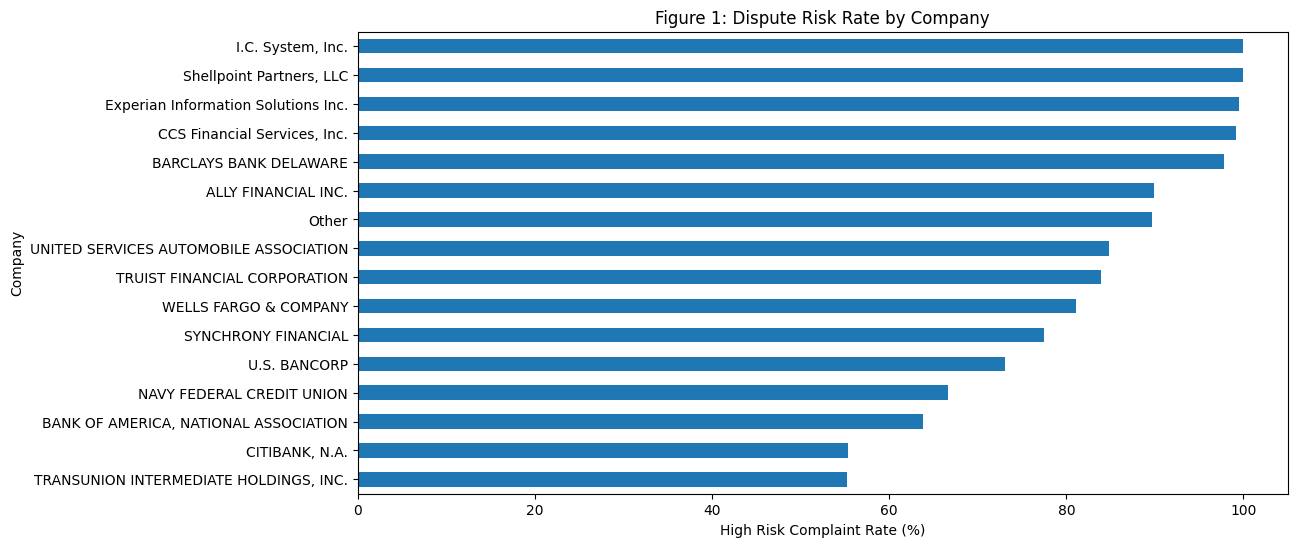

In [77]:
plt.figure(figsize=(12, 6))
risk_by_company.plot(kind="barh")
plt.title("Figure 1: Dispute Risk Rate by Company")
plt.xlabel("High Risk Complaint Rate (%)")
plt.ylabel("Company")
plt.gca().invert_yaxis()
plt.show()

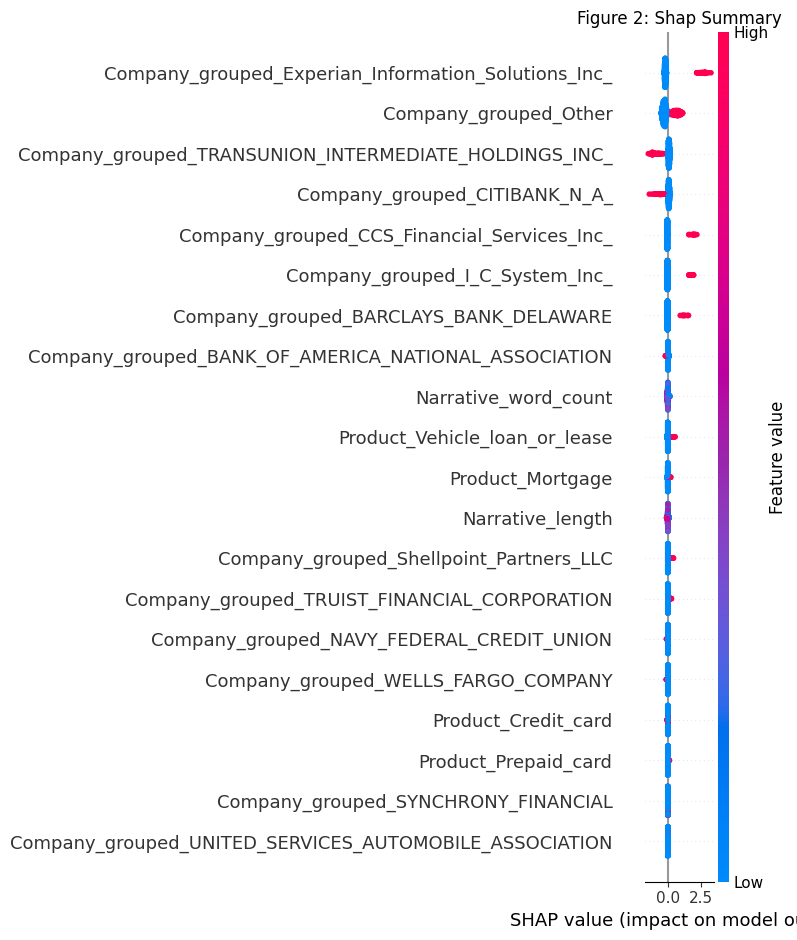

In [80]:
shap.summary_plot(structured_shap, X_test_named.iloc[:, :n_structured], feature_names=structured_names, show=False)
plt.title("Figure 2: Shap Summary")
plt.tight_layout()
plt.show()

In the above image, each dot represents 1 complaint from the test set. The dot's horizontal position shows whether that feature pushed the prediction toward high risk (right) or low risk (left) for that specific complaint. The color typically shows whether the feature's value was high (red) or low (blue) for that complaint. Features are sorted top-to-bottom by overall importance.

In [83]:
example_index = 6
example_text_clean = df["Clean Consumer complaint narrative"].iloc[example_index]
print("Complaint text:")
print(example_text_clean[:300], "...\n")

tfidf_results = get_top_tfidf_keywords(example_index, tfidf_matrix, tfidf, top_n=5)
keybert_results = get_keybert_phrases_keywords(example_text_clean, kw_model, top_n=5)
ner_results = extract_entities_with_override(example_text_clean, known_companies)

tfidf_words = [words for words, scores in tfidf_results [::-1]]
tfidf_scores = [scores for words, scores in tfidf_results [::-1]]

keybert_words = [words for words, scores in keybert_results [::-1]]
keybert_scores = [scores for words, scores in keybert_results [::-1]]

Complaint text:
For more than a year, my Citibank credit card account has been repeatedly targeted by highly sophisticated scammers who have accurate, real-time information about my account.The calls are coming from a real CITI BANK number. During these calls, the scammers know my recent and exact transactions, exa ...



Figure 3: Keyword Extraction Results


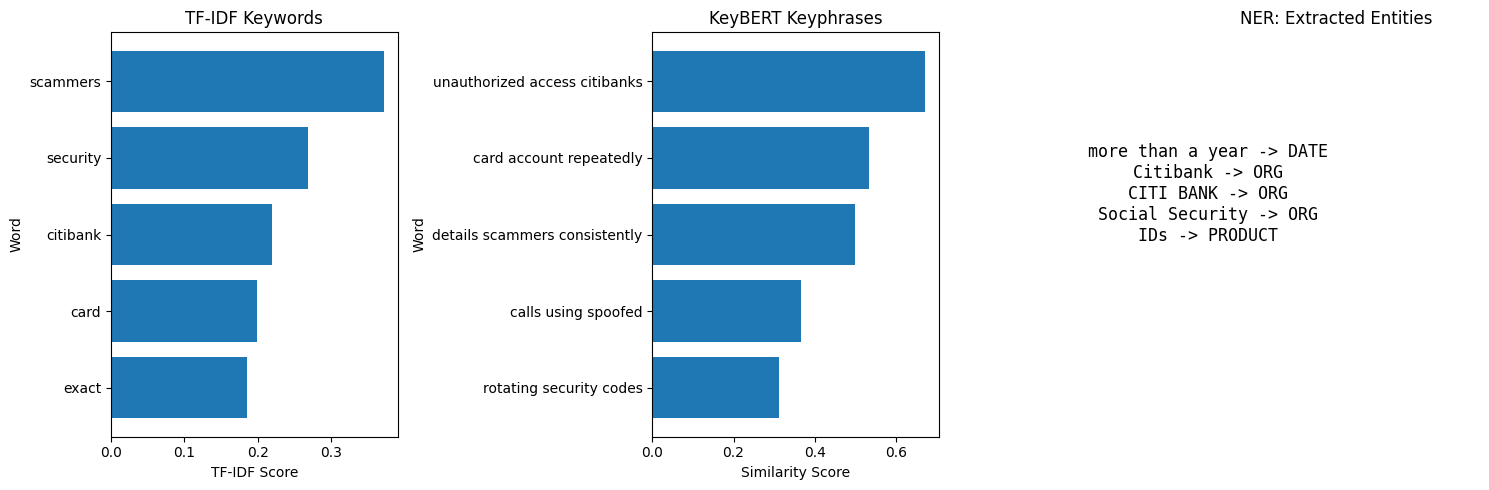

In [93]:
print("Figure 3: Keyword Extraction Results")

fig, axes = plt.subplots(1,3, figsize=(15,5))

# TF-IDF
axes[0].barh(tfidf_words, tfidf_scores)
axes[0].set_title("TF-IDF Keywords")
axes[0].set_xlabel("TF-IDF Score")
axes[0].set_ylabel("Word")

# KeyBERT
axes[1].barh(keybert_words, keybert_scores)
axes[1].set_title("KeyBERT Keyphrases")
axes[1].set_xlabel("Similarity Score")
axes[1].set_ylabel("Word")

# NER
axes[2].axis("off")
axes[2].set_title("NER: Extracted Entities", loc='center')
ner_text = "\n".join([f"{ent} -> {label}" for ent, label in ner_results])
axes[2].text(0.05, 0.6, ner_text, ha="center", va="center", family="monospace", fontsize=12)

plt.tight_layout()
plt.show()

In [94]:
result = route_complaint(6,df)
print(json.dumps(result, indent=2, default=str))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


{
  "complaint_id": "19533149",
  "complaint_text": "For more than a year, my Citibank credit card account has been repeatedly targeted by highly sophisticated scammers who have accurate, real-time information about my account.The calls are coming from a real CITI BANK number. During these calls, the scammers know my recent and exact transactions, exact name of the places I made purchase from and the amount, current exact balance, past balance, they know that I have paid my balance, card details, address, and partial Social Security number. This has continued despite multiple security actions, including several card replacements, new user IDs, password changes using strong unique passwords, account reviews with Citibanks fraud department, credit freezes, and full security monitoring. My email accounts, devices, and digital wallets are secured with multi-factor authentication and rotating security codes. I do not store my Citibank information in unsecured apps, and I do not reuse this c

## Bonus Phase: Interview Question Generator

In [98]:
def generate_review_questions(complaint_result):
    questions = []

    # Question based on compliance flag
    if complaint_result["compliance_flag"]:
        terms = ", ".join(complaint_result["flagged_terms"])
        questions.append(
            f"This complaint was flagged for compliance-sensitive language ({terms}). "
            f"Has this been escalated to the compliance/legal team for review?"
        )

    # Question based on dispute-risk level
    if complaint_result["dispute_risk_label"] == "HIGH_RISK":
        questions.append(
            f"This complaint has a high predicted dispute-risk ({complaint_result['dispute_risk_probability']*100:.1f}%). "
            f"What specific resolution steps were offered to the consumer, and were they sufficient?"
        )
    else:
        questions.append(
            f"This complaint has a lower predicted dispute-risk ({complaint_result['dispute_risk_probability']*100:.1f}%). "
            f"Confirm the resolution offered matches what similar low-risk cases typically receive."
        )

    # Question based on company history (using our earlier company-level risk rates)
    company = complaint_result["actual_company"]
    if company in risk_by_company.index:
        company_rate = risk_by_company[company]
        if company_rate > 80:
            questions.append(
                f"{company} has a historically high dispute-risk rate ({company_rate:.1f}%) in past complaints. "
                f"Is this a recurring pattern worth flagging to the account manager for {company}?"
            )

    # Question based on key phrases (grounding it in what the complaint is actually about)
    if complaint_result["key_phrases"]:
        top_phrase = complaint_result["key_phrases"][0]
        questions.append(
            f"The complaint centers on \"{top_phrase}\" — has this specific issue been directly addressed in the company's response?"
        )

    return questions

In [99]:
result = route_complaint(6, df)
questions = generate_review_questions(result)

print("Suggested Review Questions:\n")
for i, q in enumerate(questions, 1):
    print(f"{i}. {q}")

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Suggested Review Questions:

1. This complaint was flagged for compliance-sensitive language (fraud, unauthorized, scam). Has this been escalated to the compliance/legal team for review?
2. This complaint has a high predicted dispute-risk (92.8%). What specific resolution steps were offered to the consumer, and were they sufficient?
3. The complaint centers on "unauthorized access citibanks" — has this specific issue been directly addressed in the company's response?
